# 16 — the two-dimensional diagrams

Notebooks 12 to 15 fit pooled histograms. That is the right thing to do with a
cuvette, and it throws away what a single-molecule experiment is for: the
photons arrive in bursts, each burst is one molecule, and a burst can be
measured before its photons are added to anyone else's.

Sorting buys two things, and this notebook is about drawing them.

**Two rulers for one distance.** The fraction of a burst's photons that came out
red says how much energy transferred. The mean arrival time of its donor photons
says how much the donor was quenched. For a molecule at one fixed distance these
are the same measurement, and the population must lie on a line. When they
disagree, the molecule was not at one distance while it was being watched.

**The acceptor can be interrogated directly.** Under interleaved excitation the
red pulse asks whether the acceptor is there at all, so a molecule that has lost
it is identified rather than inferred. That is the stoichiometry axis.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import single_molecule as SM
from bd import P


## A static sample

Two populations at $R/R_0 = 0.80$ and $1.25$, each a single grid point — a state
a molecule occupies has one distance, and any width recovered for it is the
method's. One fifth of the molecules have no working acceptor.


In [2]:
st = P.default_settings()
st['n_bursts'] = 6000
model = P.build_model(st)
p_true, (j1, j2) = SM.two_state_truth(model, 0.80, 1.25, f1=0.5)
tab = P.physics_tables(model, st, p_true, verbose=False)
print(f'state 1: R/R0 {model["rel"][j1]:.3f}   state 2: R/R0 {model["rel"][j2]:.3f}')
print(f'donor-only fraction simulated: {st["donor_only_fraction"]:.2f}')


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
state 1: R/R0 0.799   state 2: R/R0 1.247
donor-only fraction simulated: 0.20


In [3]:
stream = SM.exchange_stream(model, st, tab, ((j1, 0.5), (j2, 0.5)),
                            t_exchange_ms=np.inf, rng=np.random.default_rng(3))
tttr, sel, bursts, feat = SM.observables(model, st, stream)
print(f'{len(feat)} bursts, median size {np.median(feat[:, 2]):.0f} photons')
print('columns:', SM.COLUMNS)


5527 bursts, median size 195 photons
columns: ('E*', 'S', 'size', 'tau', 'n_donor', 'n_sensitised', 'n_direct', 'tau_sd')


## The reference lines

Neither line is a formula here. The **static line** is the same table the
simulation draws photons from, read out one distance grid point at a time, so it
carries the multi-exponential donor, the instrument response and the crosstalk
exactly as the data do. The textbook static line is straight because it assumes
one donor lifetime, no instrument offset in the arrival time, and a proximity
ratio already corrected to an efficiency; none of the three holds, and the
departure is measured rather than waved away.

The **dynamic line** is the locus of a molecule interconverting between the two
states faster than its burst. It lies above the static line, and the reason is
worth stating: the efficiency averages the two states weighted by how many
photons each produced, while the arrival time averages them weighted by photons
*times* lifetime. A long-lived state pulls the clock further than it pulls the
intensity.


In [4]:
lt = SM.line_table(model, st, stride=4, extra=(j1, j2))
line, js = SM.static_line(model, lt)
curv, ends = SM.line_curvature(model, lt)
print(f'the static locus: {len(line)} points, arrival time {line[0,0]:.2f} to {line[-1,0]:.2f} ns, '
      f'E* {line[:,1].min():.3f} to {line[:,1].max():.3f}')
print(f'it departs from the straight line through its ends by {curv:.3f} in E*')
tau_g, gap = SM.above_static(model, lt, j1, j2)
print(f'the dynamic line rises at most {gap.max():.3f} in E* above the static one, '
      f'at an arrival time of {tau_g[np.argmax(gap)]:.2f} ns')


the static locus: 34 points, arrival time 6.16 to 8.82 ns, E* 0.144 to 0.975
it departs from the straight line through its ends by 0.731 in E*
the dynamic line rises at most 0.166 in E* above the static one, at an arrival time of 7.48 ns


## The diagram

$E^*$ against the mean donor arrival time. Two spots, both on the static line,
because nothing here moves; the donor-only bursts sit at the far right, where
the donor is unquenched and almost no red photons appear.


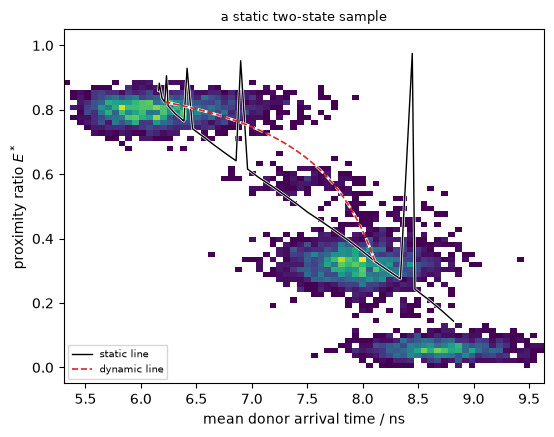

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 4.6))
SM.plot_e_tau(feat, model, lt, states=((j1, 0.5), (j2, 0.5)), ax=ax,
              title='a static two-state sample')
plt.show()


## Is that scatter physics, or arithmetic?

A static sample must sit on the line, so the spread around it should be counting
statistics and nothing else. **Two terms, and the second is the larger one.** The
proximity ratio of a burst of $n$ green-pulse photons is uncertain by
$\sqrt{E(1-E)/n}$. But the burst's mean arrival time is uncertain too, by the
spread of its donor arrival times over the root of their number — and the line is
steep, so that uncertainty appears as a vertical residual as well.

Leaving the second term out makes an ordinary static sample look four times
noisier than it should. This is the check to run *before* reading anything off a
diagram of a moving sample.


In [6]:
fret = feat[np.isfinite(feat[:, 1]) & (feat[:, 1] < 0.85)]
r = SM.scatter_about_line(fret, line); r.pop('residual')
for k, v in r.items():
    print(f'  {k:<22}{v:.4f}' if isinstance(v, float) else f'  {k:<22}{v}')


  residual_sd           0.1169
  predicted_sd          0.1379
  from_counting_E       0.0366
  from_the_clock        0.1329
  ratio                 0.8477
  median_burst_size     201.0000
  n_bursts              4431


## Stoichiometry, and what it excludes

The second laser asks the acceptor directly whether it is there. A molecule with
a working acceptor sits near one half; one that stays dark under the red pulse
goes to one.


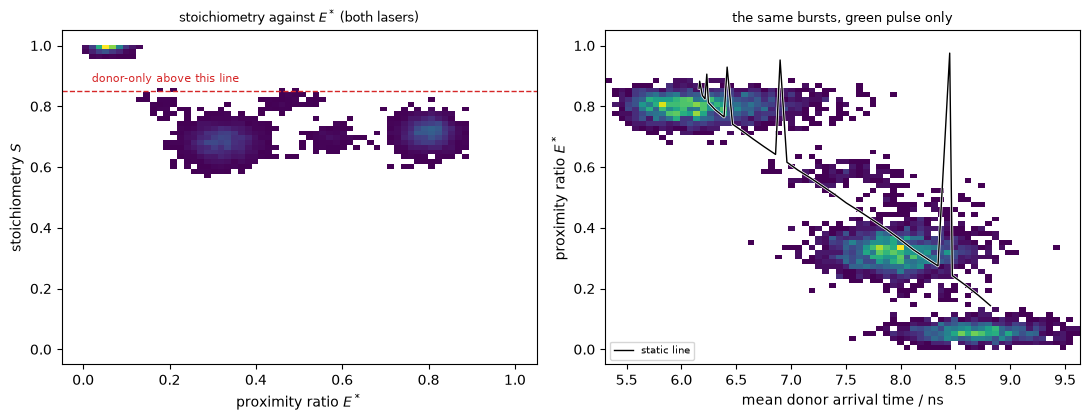

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3))
SM.plot_e_s(feat, ax=axes[0], title='stoichiometry against $E^*$ (both lasers)')
axes[0].axhline(0.85, color='C3', lw=1.0, ls='--')
axes[0].text(0.02, 0.88, 'donor-only above this line', color='C3', fontsize=8)
SM.plot_e_tau(feat, model, lt, ax=axes[1],
              title='the same bursts, green pulse only')
fig.tight_layout(); plt.show()


In [8]:
frac, n = SM.donor_only_from_s(feat, threshold=0.85)
print(f'donor-only fraction from the stoichiometry axis: {frac:.3f} over {n} bursts')
print(f'                                     simulated: {st["donor_only_fraction"]:.3f}')


donor-only fraction from the stoichiometry axis: 0.198 over 5527 bursts
                                     simulated: 0.200


The right-hand panel is the same bursts read as if the red laser had not been
there — and it is the *identical* diagram, because $E^*$ and the arrival time
are both formed from green-pulse photons alone. **So the lifetime diagram is
available in both geometries and the stoichiometry axis is not.**

That is what the second laser buys, stated as a picture rather than as a claim:
without it the donor-only population is not a cluster you can point at, and the
fit has to infer it from the shape of the decays. Notebook 12 fitted exactly
that geometry, and its identifiability table put the donor-only fraction at a
data share of 0.999 — determined, but by the decay shape rather than by a
direct measurement of the acceptor.

## What this notebook establishes

* The two rulers agree for a static sample: the bursts scatter about the line
  by 0.85 of what counting statistics predict, once the clock's own
  uncertainty is counted. Below one means the prediction is slightly
  conservative, which it should be -- it treats the local slope as exact.
* Most of the vertical spread in this diagram comes from the arrival-time axis,
  not from the intensity axis.
* The static locus for this model is a curve, not the textbook straight line,
  and the difference is not small.
* The stoichiometry axis measures the donor-only fraction directly, to within
  0.01 of the simulated value.

What it does **not** establish is anything about a sample that moves. Notebook
17 makes the molecules interconvert.
